In [1]:
import pandas as pd
import numpy as np
from sklearn.preprocessing import StandardScaler
from sklearn.mixture import GaussianMixture
import matplotlib.pyplot as plt
import os


In [2]:
# Leakage discipline: the GMM (and its StandardScaler / PCA) is fit on the
# TRAIN partition only; test rows are only ever scored with `.predict` /
# `.predict_proba`. Same frozen split as every supervised notebook
# (src/split.py: stratified on fit_label, test_size=0.20, random_state=42).
import sys
sys.path.append("../../src")
from split import load_rtr_with_split

df = load_rtr_with_split()

### Train/test discipline

The scaler, the BIC/AIC model-selection sweep, the final GMM, and the PCA used
for visualization are all fit on the **training partition only** (`src/split.py`
— the same frozen split used by every supervised notebook). Cluster labels and
confidences for test rows are produced with `predict` / `predict_proba`
(inference only). The saved `gmm_df.csv` is de-duplicated on `(user_id, item_id)`.


In [3]:
df.describe()

,user_id,item_id,fit_label,height_inches,weight_lbs,bmi,bust_band,cup_size_num,size,age,body_type_num,rented_for_num,rating,review_year,review_month,row_id
count,192544.000000,1.925440e+05,192544.000000,191867.000000,162562.000000,162118.000000,174133.000000,174133.000000,192544.000000,191584.000000,177907.000000,192534.000000,192462.000000,192544.000000,192544.000000,192544.000000
mean,499494.100149,1.045684e+06,0.994432,65.310621,137.391709,22.670947,34.201271,2.958239,12.245175,33.871017,2.964318,4.339935,9.092371,2015.687786,6.851727,96271.500000
std,289059.719328,8.053148e+05,0.512031,2.663480,21.899967,3.380015,1.745246,1.158004,8.494877,8.058083,1.636881,2.498000,1.430044,1.335570,3.380067,55582.809453
min,9.000000,1.233730e+05,0.000000,54.000000,50.000000,8.069330,28.000000,0.000000,0.000000,0.000000,0.000000,0.000000,2.000000,2010.000000,1.000000,0.000000
25%,250654.250000,1.950760e+05,1.000000,63.000000,123.000000,20.372405,34.000000,2.000000,8.000000,29.000000,1.000000,2.000000,8.000000,2015.000000,4.000000,48135.750000
50%,499419.000000,9.483960e+05,1.000000,65.000000,135.000000,21.968750,34.000000,3.000000,12.000000,32.000000,3.000000,4.000000,10.000000,2016.000000,7.000000,96271.500000
75%,750974.000000,1.678888e+06,1.000000,67.000000,148.000000,24.126627,36.000000,4.000000,16.000000,37.000000,4.000000,7.000000,10.000000,2017.000000,10.000000,144407.250000
max,999997.000000,2.966087e+06,2.000000,78.000000,300.000000,54.527435,48.000000,10.000000,58.000000,117.000000,6.000000,8.000000,10.000000,2018.000000,12.000000,192543.000000


In [4]:
print(df.isnull().sum())

user_id                0
item_id                0
fit                    0
fit_label              0
height_inches        677
weight_lbs         29982
bmi                30426
bust_band          18411
cup_size_letter    18411
cup_size_num       18411
size                   0
age                  960
category               0
body_type          14637
body_type_num      14637
rented_for            10
rented_for_num        10
rating                82
review_summary       347
review_text           68
review_date            0
review_year            0
review_month           0
row_id                 0
split                  0
dtype: int64


# fit target: whether it's small, fits, large

In [5]:
body_features = [
    'height_inches', 'weight_lbs', 'bmi',
    'bust_band', 'cup_size_num', 'body_type_num', 'age'
]

df_body = df[body_features].copy()

In [6]:
df_body_clean = df_body.dropna()
print(f"Rows retained: {len(df_body_clean):,} / {len(df_body):,} ({len(df_body_clean)/len(df_body):.1%})")

# Train/test mask aligned to the complete-case rows.
body_train_mask = df.loc[df_body_clean.index, "split"].to_numpy() == "train"
print(f"  train complete-cases: {body_train_mask.sum():,}   "
      f"test complete-cases: {(~body_train_mask).sum():,}")

Rows retained: 146,438 / 192,544 (76.1%)
  train complete-cases: 117,071   test complete-cases: 29,367


In [7]:
# Fit the scaler on TRAIN complete-cases only, then transform everything.
scaler = StandardScaler()
scaler.fit(df_body_clean[body_train_mask])

X_scaled = scaler.transform(df_body_clean)      # all complete cases
X_train_scaled = X_scaled[body_train_mask]      # train complete cases only

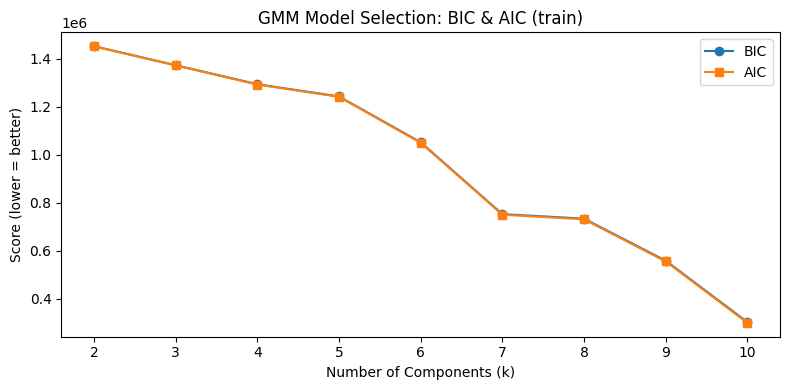

In [8]:
bic_scores = []
aic_scores = []
k_range = range(2, 11)

for k in k_range:
    gmm = GaussianMixture(n_components=k, covariance_type='full',
                          random_state=42, n_init=3)
    gmm.fit(X_train_scaled)                       # model selection on TRAIN only
    bic_scores.append(gmm.bic(X_train_scaled))
    aic_scores.append(gmm.aic(X_train_scaled))


# Set your figure folder path here
fig_folder = "../../Figures/Unsupervised_Outputs"

# Create folder if it doesn't exist
os.makedirs(fig_folder, exist_ok=True)

fig, ax = plt.subplots(figsize=(8, 4))
ax.plot(k_range, bic_scores, marker='o', label='BIC')
ax.plot(k_range, aic_scores, marker='s', label='AIC')
ax.set_xlabel('Number of Components (k)')
ax.set_ylabel('Score (lower = better)')
ax.set_title('GMM Model Selection: BIC & AIC (train)')
ax.legend()
plt.tight_layout()
fig.savefig(os.path.join(fig_folder, "gmm_bic_aic.png"), dpi=150, bbox_inches='tight')
plt.show()

In [9]:
k_optimal = 5

gmm_final = GaussianMixture(
    n_components=k_optimal,
    covariance_type='full',
    random_state=42,
    n_init=5
)
gmm_final.fit(X_train_scaled)          # fit on TRAIN only

GaussianMixture(n_components=5, n_init=5, random_state=42)

In [10]:
# ── 6. ASSIGN CLUSTERS + SOFT PROBABILITIES ───────────────────────────────────
# predict / predict_proba are inference-only: test rows are scored by the
# train-fit model, never used to fit it.
df_body_clean = df_body_clean.copy()
df_body_clean['body_cluster']       = gmm_final.predict(X_scaled)
df_body_clean['cluster_confidence'] = gmm_final.predict_proba(X_scaled).max(axis=1)

# Drop columns if they already exist (from a previous run)
df = df.drop(columns=['body_cluster', 'cluster_confidence'], errors='ignore')

# # Merge clusters back to original df on index
df = df.join(df_body_clean[['body_cluster', 'cluster_confidence']])
print(df.head())
# # ── 7. PROFILE EACH CLUSTER (train rows) ──────────────────────────────────────
cluster_profiles = (
    df_body_clean[body_train_mask].groupby('body_cluster')[body_features].median()
)
print(cluster_profiles)

   user_id  item_id  fit  fit_label  height_inches  weight_lbs        bmi  \
0   420272  2260466  fit          1           68.0       137.0  20.828503   
1   273551   153475  fit          1           66.0       132.0  21.303030   
2   360448  1063761  fit          1           64.0         NaN        NaN   
3   909926   126335  fit          1           65.0       135.0  22.462722   
4   151944   616682  fit          1           69.0       145.0  21.410418   

   bust_band cup_size_letter  cup_size_num  ...  rating  \
0       34.0               d           4.0  ...    10.0   
1       34.0               b           2.0  ...    10.0   
2        NaN             NaN           NaN  ...    10.0   
3       34.0               c           3.0  ...     8.0   
4       34.0               b           2.0  ...    10.0   

                                      review_summary  \
0                               So many compliments!   
1                            I felt so glamourous!!!   
2  It was a gr

In [11]:
cluster_profiles.shape

(5, 7)

In [12]:
# De-duplicate on the (user_id, item_id) key the supervised notebooks merge on,
# so the join stays 1:1 (renttherunway_clean.csv has 266 duplicate transaction
# rows).
gmm_out = df.drop_duplicates(subset=["user_id", "item_id"]).reset_index(drop=True)
assert not gmm_out.duplicated(subset=["user_id", "item_id"]).any()
print(f"gmm_df rows (unique user_id+item_id): {len(gmm_out):,}")

gmm_out.to_csv(
    "../../Data/Processed/Unsupervised_Outputs/gmm_df.csv",
    index=False
)

gmm_df rows (unique user_id+item_id): 192,278


In [13]:
cluster_profiles.to_csv(
    "../../Data/Processed/Unsupervised_Outputs/gmm_cluster_profiles.csv",
    index=True
)

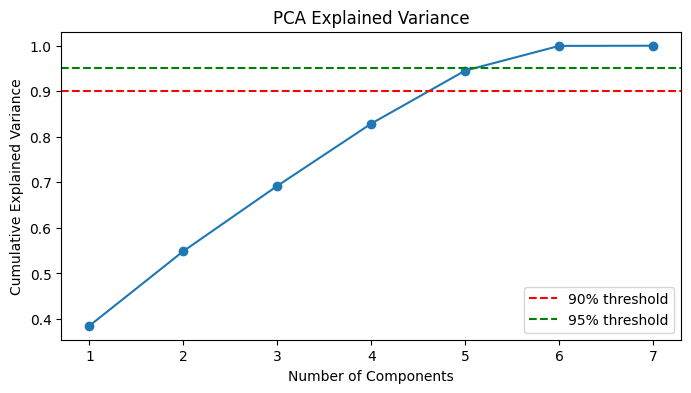

In [14]:
from sklearn.decomposition import PCA

# Fit PCA on TRAIN only; used for the variance plot and as t-SNE input.
pca_full = PCA()
pca_full.fit(X_train_scaled)

# Plot explained variance
cumulative_variance = pca_full.explained_variance_ratio_.cumsum()

fig_var, ax_var = plt.subplots(figsize=(8, 4))
ax_var.plot(range(1, len(cumulative_variance)+1), cumulative_variance, marker='o')
ax_var.axhline(y=0.90, color='r', linestyle='--', label='90% threshold')
ax_var.axhline(y=0.95, color='g', linestyle='--', label='95% threshold')
ax_var.set_xlabel('Number of Components')
ax_var.set_ylabel('Cumulative Explained Variance')
ax_var.set_title('PCA Explained Variance')
ax_var.legend()
fig_var.savefig(os.path.join(fig_folder, "gmm_PCA_variance.png"), dpi=150, bbox_inches='tight')
plt.show()

In [15]:
from sklearn.decomposition import PCA
from sklearn.manifold import TSNE

# PCA fit on TRAIN, applied to all complete-case rows (t-SNE input).
pca = PCA(n_components=5)
pca.fit(X_train_scaled)
X_pca = pca.transform(X_scaled)

In [16]:
# Create PCA dataframe
pca_cols = [f'PC{i+1}' for i in range(5)]
df_pca_5d = pd.DataFrame(
    X_pca,
    columns=pca_cols,
    index=df_body_clean.index
)

# (Optional but recommended) attach cluster + confidence
df_pca_5d['body_cluster'] = df_body_clean['body_cluster']
df_pca_5d['cluster_confidence'] = df_body_clean['cluster_confidence']

# Output path
pca_out_path = "../../Data/Processed/Unsupervised_Outputs/gmm_pca_5d_body_features.csv"

# Save to CSV
df_pca_5d.to_csv(pca_out_path, index=True)

print(f"Saved PCA results to: {pca_out_path}")

Saved PCA results to: ../../Data/Processed/Unsupervised_Outputs/gmm_pca_5d_body_features.csv


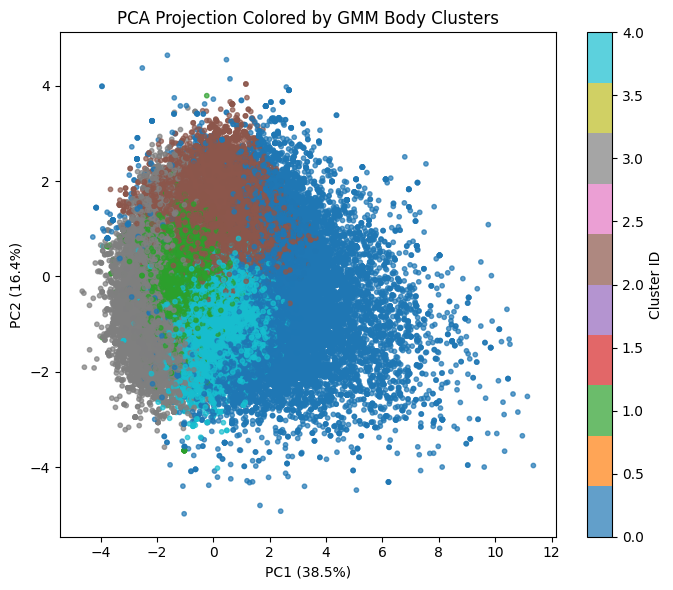

In [17]:
pca_2d = PCA(n_components=2)
pca_2d.fit(X_train_scaled)
X_pca_2d = pca_2d.transform(X_scaled)

plt.figure(figsize=(7, 6))
scatter = plt.scatter(
    X_pca_2d[:, 0],
    X_pca_2d[:, 1],
    c=df_body_clean['body_cluster'],
    cmap='tab10',
    s=10,
    alpha=0.7
)

plt.xlabel(f"PC1 ({pca_2d.explained_variance_ratio_[0]:.1%})")
plt.ylabel(f"PC2 ({pca_2d.explained_variance_ratio_[1]:.1%})")
plt.title("PCA Projection Colored by GMM Body Clusters")
plt.colorbar(scatter, label="Cluster ID")
plt.tight_layout()
plt.savefig(
    os.path.join(fig_folder, "gmm_pca_2d_clusters.png"),
    dpi=150,
    bbox_inches="tight"
)
plt.show()

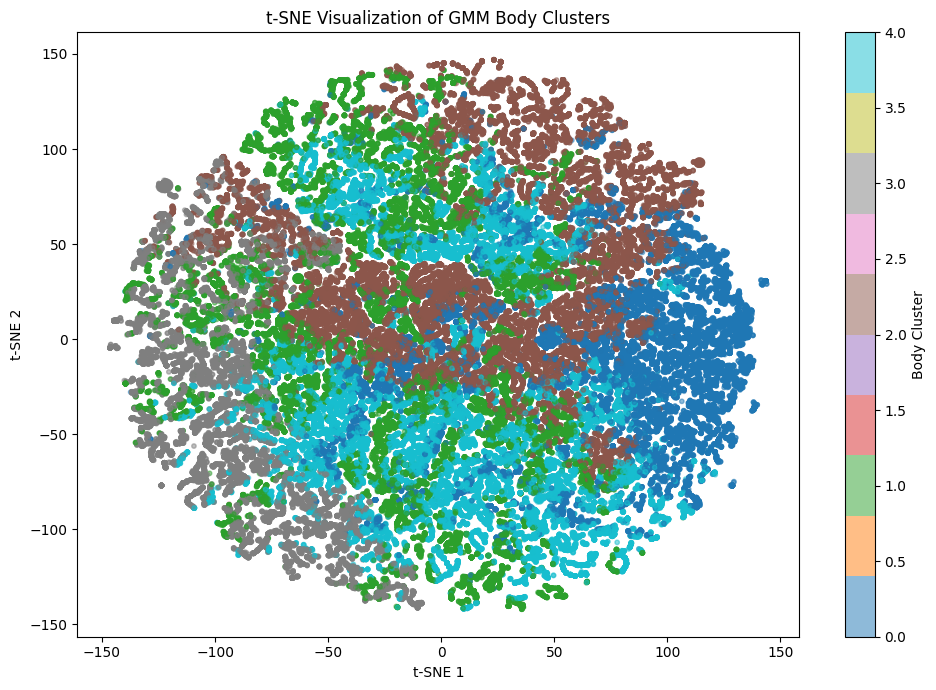

In [18]:

# t-SNE on PCA output 
tsne = TSNE(n_components=2, random_state=42, perplexity=30, max_iter=1000)
X_tsne = tsne.fit_transform(X_pca)

# Plot colored by GMM cluster
plt.figure(figsize=(10, 7))
scatter = plt.scatter(X_tsne[:, 0], X_tsne[:, 1], 
                      c=df_body_clean['body_cluster'], 
                      cmap='tab10', alpha=0.5, s=10)
plt.colorbar(scatter, label='Body Cluster')
plt.title('t-SNE Visualization of GMM Body Clusters')
plt.xlabel('t-SNE 1')
plt.ylabel('t-SNE 2')
plt.tight_layout()
plt.savefig(os.path.join(fig_folder, "gmm_tsne_clusters.png"), dpi=150, bbox_inches='tight')
plt.show()

In [19]:
X_tsne_df = pd.DataFrame(X_tsne, columns=['tsne_1', 'tsne_2'])
X_tsne_df.to_csv(
    "../../Data/Processed/Unsupervised_Outputs/gmm_pca_tsne.csv",
    index=False
)

# Gaussian Mixture Model (GMM) – Body Cluster Analysis

### Overview
A Gaussian Mixture Model was applied to cluster users by body measurements using 7 features: height, weight, BMI, bust band, cup size, body type, and age. Unlike hard-assignment methods like K-Means, GMM fits probabilistic Gaussian distributions over the data, assigning each user a soft cluster membership and a confidence score — better suited to body measurement data where the boundaries between body types are inherently continuous and overlapping.

### Model Selection
BIC and AIC were evaluated for k = 2 through 10 using covariance_type='full'. Both scores decrease steadily across the range, with a sharp dip at k = 9 before rising again at k = 10, indicating k = 9 as the statistical optimum. However, k = 5 was selected for the final model to balance statistical fit with interpretability — five clusters map more naturally to meaningful body type groupings and reduce noise from over-segmentation.

### Cluster Structure
The PCA projection (PC1 = 38.5%, PC2 = 16.4%, ~55% combined variance) shows the five clusters arranged along a clear gradient from left to right on PC1, which likely captures the dominant axis of body size variation. Clusters 0 (blue) and 4 (cyan) anchor opposite ends of this spectrum, with clusters 1 (green), 2 (brown), and 3 (gray) occupying the middle range with moderate overlap.

The t-SNE visualization confirms this structure at a non-linear level — clusters 1 and 4 form the most spatially coherent regions, while clusters 2 and 3 show significant intermixing in the center, consistent with overlapping body proportions in the mid-range. This overlap is expected and is precisely where GMM's soft assignments add value over hard clustering.